# 运动想象解码 Benchmark Project:BCICIV-2a vs Lee2019

该notebook用于展示本人独立完成的一个运动想象解码 benchmark 的结果。

本项目在两个公开的运动想象(MI)数据集 BCICIV-2a(9 人、4 类)和 Lee2019(54 人、2 类)上,对比四种解码方法(CSP+LDA、黎曼 MDM、黎曼 TS-LR、EEGNet)和一个无监督域适应方法(RPA,实现并在跨域协议上验证)。四种评估协议按部署真实度排序：会话内5折CV、通道缩减(全montage砍到4通道)、跨会话、跨被试LOSO,两个数据集都跑。两个数据集随机水平不同(25% vs 50%),跨数据集比较用 κ 归一化,并报告效应量 dz 与 Holm 校正后的显著性。

本notebook的模块目录:项目动机、实验设计、三个核心发现(TS-LR最稳 / RPA恢复退化 / 深度学习何时划算)、工程化部署检查、结论。

> 所有计算都在 `.py` 脚本里离线跑,这个 notebook 只负责读结果和画图,不重新计算。

## 项目动机:真正的瓶颈不是会话内精度,而是换人+换天的精度掉落

把一个MI解码器做到实验室同会话高精度并不难;真正决定能不能落地的,是它在换一天（会话）、换一个人之后还剩多少精度。

- 实验室精度与部署精度之间的差距,主要来自跨会话(同一个人不同天,脑电协方差漂移)和跨被试(全新用户,个体差异)两类分布偏移。
- 对一个商用或临床BCI设备,成本核心是每个新用户的标定负担：用户要先采多少标定数据,才能达到可用精度。
- 本项目把这个掉落量化出来(退化有多大、在多少样本下才统计可见),并验证一个无监督的恢复方法(RPA,不需要目标域标签),从而压低标定负担。

下面所有协议都围绕这个问题设计:从会话内,到通道缩减,到跨会话,再到跨被试,逐级逼近真实部署压力。

## 实验设计:4 种解码器 x 2 数据集 x 4 种评估协议

方法覆盖四个方法族: 
- CSP+LDA (空间滤波)
- 黎曼MDM (流形上的生成式)
- 黎曼TS-LR (流形切空间判别式)
- EEGNet (端到端深度网络)。

| | BCICIV-2a | Lee2019_MI |
|---|---|---|
| 类别 | 4 类(左/右手、脚、舌) | 2 类(左/右手) |
| 随机水平 | 25% | 50% |
| 被试 | 9 | 54 |
| 每会话 trial | **288**(72/类) | **100**(50/类) |
| 通道 | 22 | 62 |

四种协议按部署真实度从低到高排列:会话内5折CV、通道缩减(全montage砍到4通道)、跨会话(换天)、跨被试LOSO(换人、零标定),每一档隔离一种不同的部署压力。注:会话内基线就是通道缩减表里的全通道点(2a K=22 / Lee2019 K=62)。

Note: 类别数不同,两个数据集的绝对准确率不能直接比,跨数据集对比用归一化的 κ = (acc - chance) / (1 - chance)

## 数据来源与复现

下面的数字全部来自 `results/` 里的文件,由实验脚本离线生成,notebook 只读不算。会话内基线就是通道缩减表里的全通道点(2a K=22 / Lee2019 K=62)。

| 文件 | 生成脚本 | 内容 |
|---|---|---|
| `exp_2a_channel_reduction.csv` | `run_channel_reduction.py` | 2a(9 人):会话内 5 折 CV,通道 22 缩到 4 |
| `exp_2a_baseline.csv` | `run_cross_session.py` | 2a(9 人):跨会话 |
| `exp_lee2019_channel_reduction.csv` | `run_lee2019_overnight.py` | Lee2019(54 人):会话内 5 折 CV,通道 62 缩到 4 |
| `exp_lee2019_cross_session.csv` | `run_lee2019_overnight.py` | Lee2019(54 人):跨会话 |
| `exp_2a_loso_extended.csv` / `exp_lee2019_loso_extended.csv` | `run_cross_subject.py` | 跨被试 LOSO(含 TS-LR-RPA、EEGNet-LOSO@50ep) |
| `onnx_deploy_check.json` | `run_onnx_deploy_check.py` | ONNX 导出延迟 + 部署一致性 summary |

In [1]:
%matplotlib inline
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from pathlib import Path
from scipy.stats import wilcoxon, friedmanchisquare

RESULTS = Path("../results")
BASE = ["CSP+LDA", "MDM", "TS-LR", "EEGNet"]
COLORS = {"CSP+LDA": "#4C72B0", "MDM": "#55A868", "TS-LR": "#C44E52", "EEGNet": "#8172B3"}
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3, "font.size": 10})

lee_cross = pd.read_csv(RESULTS / "exp_lee2019_cross_session.csv")
lee_cr    = pd.read_csv(RESULTS / "exp_lee2019_channel_reduction.csv")
a_cross   = pd.read_csv(RESULTS / "exp_2a_baseline.csv").query("protocol == 'cross-session'")
a_cr      = pd.read_csv(RESULTS / "exp_2a_channel_reduction.csv")

kappa = lambda acc, chance: (acc - chance) / (1 - chance)
def dz(a, b):
    d = (a - b).dropna(); return d.mean() / d.std()
print("loaded:", lee_cross.shape, lee_cr.shape, a_cross.shape, a_cr.shape)

loaded: (270, 4) (1080, 4) (45, 4) (180, 4)


## 发现一:黎曼切空间 + 逻辑回归(TS-LR)几乎全协议最好

把四种协议放在一起看:TS-LR几乎在每一档都最好。

被试内的三档(会话内、通道缩减、跨会话),含通道缩减扫描的12个「通道数 x 协议」格子里它占了 11 个第一名,唯一例外是 2a 砍到 4 通道时被EEGNet在噪声级反超(0.563 vs 0.553,差不到一个 SD)。第四档跨被试LOSO:base TS-LR 在 Lee2019 仍第二、2a 上与 CSP/EEGNet 三者并列,但加上我实现的 RPA 后两个数据集都回到TOP1(详见发现二)。

### 通道缩减:全 montage 砍到 4 通道,看各方法准确率变化(同会话 5 折 CV)


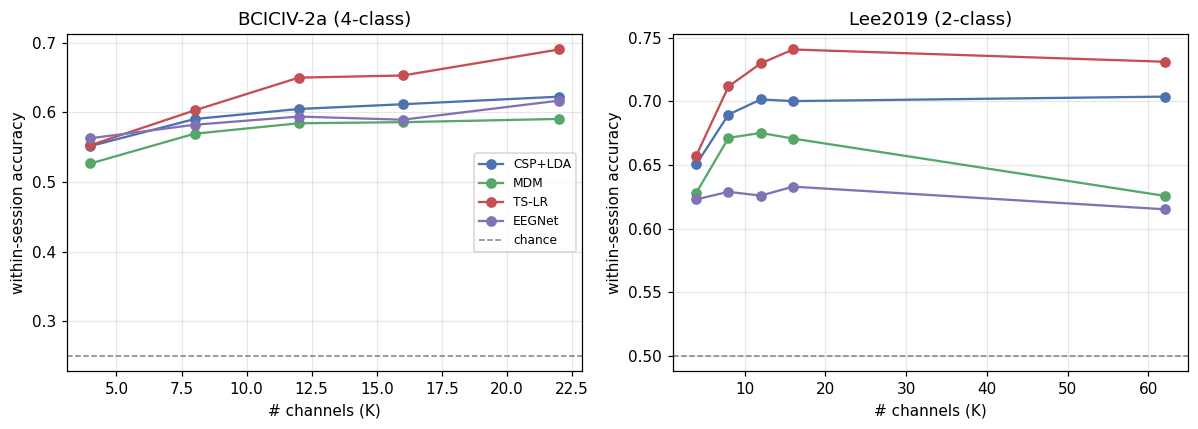

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, (name, cr, chance) in zip(axes, [("BCICIV-2a (4-class)", a_cr, 0.25),
                                         ("Lee2019 (2-class)", lee_cr, 0.50)]):
    ks = sorted(cr.n_channels.unique())
    for m in BASE:
        means = [cr[(cr.method == m) & (cr.n_channels == k)].score.mean() for k in ks]
        ax.plot(ks, means, "o-", color=COLORS[m], label=m)
    ax.axhline(chance, ls="--", c="gray", lw=1, label="chance")
    ax.set_title(name); ax.set_xlabel("# channels (K)"); ax.set_ylabel("within-session accuracy")
axes[0].legend(fontsize=8)
fig.tight_layout(); plt.show()

通道多的时候 **TS-LR明显领先**(CSP+LDA在Lee2019上也接近);砍到 4 通道时各方法差距收窄。**依赖全脑协方差结构的方法(TS-LR、CSP)降幅最大**:2a上TS-LR的dz达+2.84,通道减少后这一优势消失。

### 全协议总览：四种base方法在 within-session / cross-session / cross-subject 上的表现

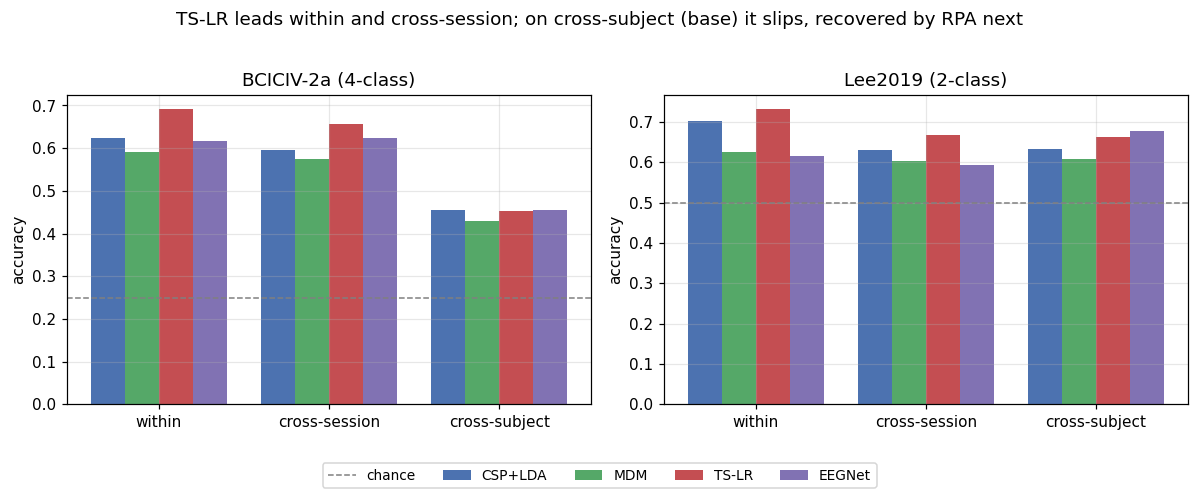

In [3]:
# TS-LR's general status: 4 base methods across within / cross-session / cross-subject
a_loso_b = pd.read_csv(RESULTS / "exp_2a_loso_extended.csv").pivot_table(index="subject", columns="method", values="score")
l_loso_b = pd.read_csv(RESULTS / "exp_lee2019_loso_extended.csv").pivot_table(index="subject", columns="method", values="score")
protos = ["within", "cross-session", "cross-subject"]
fig, axes = plt.subplots(1, 2, figsize=(11, 4.4))
for ax, (name, cr, fullK, crossdf, loso, chance) in zip(axes, [
        ("BCICIV-2a (4-class)", a_cr, 22, a_cross, a_loso_b, 0.25),
        ("Lee2019 (2-class)", lee_cr, 62, lee_cross, l_loso_b, 0.50)]):
    vals = {
        "within": {m: cr[(cr.method == m) & (cr.n_channels == fullK)].score.mean() for m in BASE},
        "cross-session": {m: crossdf[crossdf.method == m].score.mean() for m in BASE},
        "cross-subject": {m: loso[m].mean() for m in BASE},
    }
    x = np.arange(len(protos)); w = 0.2
    for j, m in enumerate(BASE):
        ax.bar(x + (j - 1.5) * w, [vals[p][m] for p in protos], w, color=COLORS[m], label=m)
    ax.axhline(chance, ls="--", c="gray", lw=1, label="chance")
    ax.set_xticks(x); ax.set_xticklabels(protos); ax.set_title(name); ax.set_ylabel("accuracy")
h, l = axes[0].get_legend_handles_labels()
fig.legend(h, l, loc="lower center", ncol=5, fontsize=9, bbox_to_anchor=(0.5, -0.02))
fig.suptitle("TS-LR leads within and cross-session; on cross-subject (base) it slips, recovered by RPA next")
fig.tight_layout(rect=[0, 0.08, 1, 0.96]); plt.show()

四种 base 方法在三档协议上的总览:**TS-LR 在会话内和跨会话两档、两个数据集上都是第一**(Lee2019 跨会话经 Holm 校正后仍显著优于其余三个)。到最难的跨被试(全新用户),base方法里 TS-LR不再领先(2a上与CSP/EEGNet三者并列约0.45,Lee2019上被EEGNet 0.677反超),这一档的掉落正是发现二要用RPA补回的。

## 发现二：部署漂移,换天(跨会话)和换人(跨被试)都会掉,RPA有效将两种掉落补回来

量化动机里说的两类分布偏移：跨会话(同一个人不同天)和跨被试(全新用户、零标定)。先看四种方法各掉多少,再看我实现并验证的 RPA(无监督黎曼 re-centering:把目标域协方差的黎曼均值对齐到训练域参考点,不用任何目标标签)如何同时补回这两种掉落。

### 退化:每种方法从会话内、跨会话到跨被试各掉多少(按方法分组)

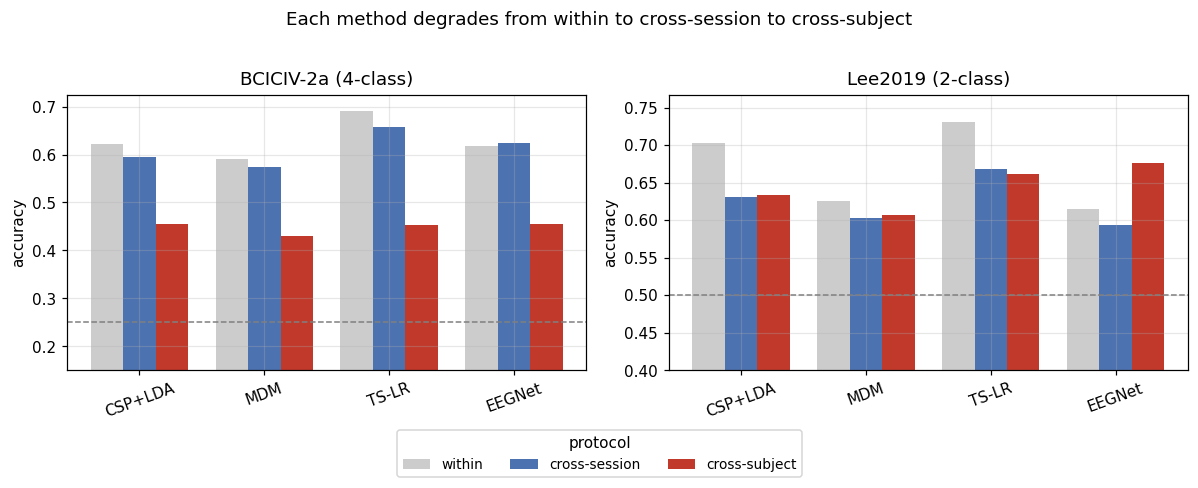

2a within to cross-session drop (paired Wilcoxon):
  CSP+LDA  delta=+0.027  p=5.0e-01
  MDM      delta=+0.017  p=3.6e-01
  TS-LR    delta=+0.033  p=5.5e-02
  EEGNet   delta=-0.007  p=1.0e+00
Lee2019 within to cross-session drop (paired Wilcoxon):
  CSP+LDA  delta=+0.072  p=2.8e-05
  MDM      delta=+0.023  p=2.2e-02
  TS-LR    delta=+0.062  p=2.7e-05
  EEGNet   delta=+0.022  p=1.0e-01
2a within to cross-subject drop (paired Wilcoxon):
  CSP+LDA  delta=+0.167  p=3.9e-03
  MDM      delta=+0.161  p=3.9e-03
  TS-LR    delta=+0.238  p=3.9e-03
  EEGNet   delta=+0.163  p=3.9e-03
Lee2019 within to cross-subject drop (paired Wilcoxon):
  CSP+LDA  delta=+0.071  p=2.1e-04
  MDM      delta=+0.018  p=2.5e-01
  TS-LR    delta=+0.069  p=1.5e-05
  EEGNet   delta=-0.061  p=2.6e-04


In [4]:
# degradation per method: accuracy across within / cross-session / cross-subject (protocol-clustered)
protos = ["within", "cross-session", "cross-subject"]
pcol = {"within": "#cccccc", "cross-session": "#4C72B0", "cross-subject": "#C0392B"}
fig, axes = plt.subplots(1, 2, figsize=(11, 4.3))
for ax, (name, cr, fullK, crossdf, loso, chance) in zip(axes, [
        ("BCICIV-2a (4-class)", a_cr, 22, a_cross, a_loso_b, 0.25),
        ("Lee2019 (2-class)", lee_cr, 62, lee_cross, l_loso_b, 0.50)]):
    vals = {
        "within": {m: cr[(cr.method == m) & (cr.n_channels == fullK)].score.mean() for m in BASE},
        "cross-session": {m: crossdf[crossdf.method == m].score.mean() for m in BASE},
        "cross-subject": {m: loso[m].mean() for m in BASE},
    }
    x = np.arange(len(BASE)); w = 0.26
    for k, proto in enumerate(protos):
        ax.bar(x + (k - 1) * w, [vals[proto][m] for m in BASE], w, color=pcol[proto], label=proto)
    ax.axhline(chance, ls="--", c="gray", lw=1)
    ax.set_ylim(bottom=chance-0.1)
    ax.set_xticks(x); ax.set_xticklabels(BASE, rotation=20); ax.set_title(name); ax.set_ylabel("accuracy")
h, l = axes[0].get_legend_handles_labels()
fig.legend(h, l, loc="lower center", ncol=3, fontsize=9, title="protocol", bbox_to_anchor=(0.5, -0.02))
fig.suptitle("Each method degrades from within to cross-session to cross-subject")
fig.tight_layout(rect=[0, 0.08, 1, 0.96]); plt.show()

# the cross-session drop is paired-testable: not significant at n=9 (2a), significant at n=54 (Lee)
for name, cr, fullK, crossdf in [("2a", a_cr, 22, a_cross), ("Lee2019", lee_cr, 62, lee_cross)]:
    win = cr[cr.n_channels == fullK].pivot_table(index="subject", columns="method", values="score")
    crs = crossdf[crossdf.method.isin(BASE)].pivot_table(index="subject", columns="method", values="score")
    print(f"{name} within to cross-session drop (paired Wilcoxon):")
    for m in BASE:
        a, b = win[m].align(crs[m], join="inner")
        print(f"  {m:8s} delta={(a - b).mean():+.3f}  p={wilcoxon(a, b)[1]:.1e}")

# within -> cross-subject drop (subject-paired): the new-user shift is much larger
for name, cr, fullK, loso in [("2a", a_cr, 22, a_loso_b), ("Lee2019", lee_cr, 62, l_loso_b)]:
    win = cr[cr.n_channels == fullK].pivot_table(index="subject", columns="method", values="score")
    print(f"{name} within to cross-subject drop (paired Wilcoxon):")
    for m in BASE:
        a, b = win[m].align(loso[m], join="inner")
        print(f"  {m:8s} delta={(a - b).mean():+.3f}  p={wilcoxon(a, b)[1]:.1e}")

**2a:跨会话退化少,跨被试退化多：** 跨会话上各方法只掉约0.02到0.03,且n=9下都不显著(TS-LR, p=0.055)。跨被试上则大幅下降(TS-LR掉0.24),9 个被试全部下降。原因是只有8个训练被试,学不到跨人不变的特征。

**Lee:跨会话退化更明显,跨被试退化(相对2a)小得多：** 跨会话上CSP/TS-LR各掉约0.06到0.07,n=54下显著(p<3e-5)；跨被试上的退化降到和跨会话相当(各约 0.07),远小于2a的平均0.18掉落。原因是53个训练被试足以泛化到新用户。(跨会话比 2a 大,与 Lee 每会话trial更少一致,但两数据集还差在类别数/通道/人群,trial数无法单独归因,作观察、不下因果。)

**EEGNet的例外：在 Lee 上它的跨被试不仅没退化,反而冲破了同会话的ceiling(从0.615升到0.677,p=2.6e-4)。**

### RPA修复TS-LR的两种掉落(以会话内为天花板,看补回了多少)

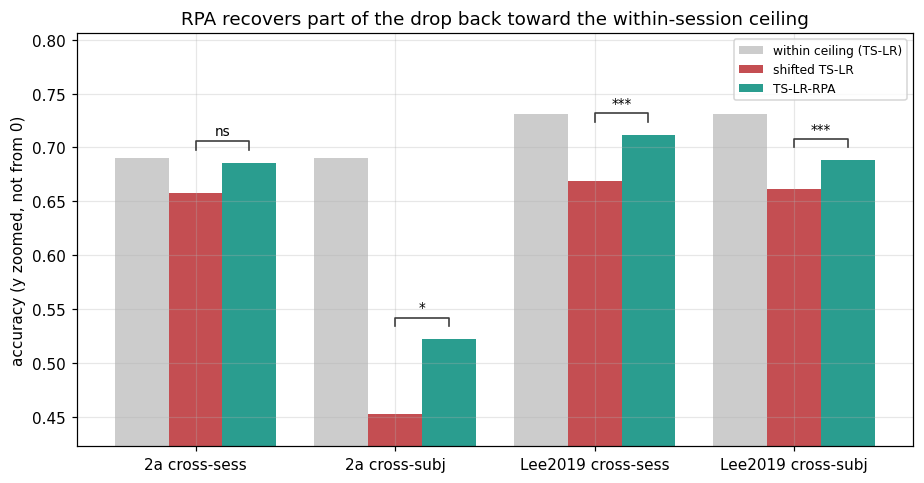

RPA recovery toward the within-session ceiling:
  2a cross-sess    drop 0.033, recovered +0.028 (85% of drop), p=5.5e-02
  2a cross-subj    drop 0.238, recovered +0.069 (29% of drop), p=2.0e-02
  Lee2019 cross-sess drop 0.062, recovered +0.043 (69% of drop), p=2.5e-05
  Lee2019 cross-subj drop 0.069, recovered +0.026 (38% of drop), p=2.8e-04
rank-1 (best) method per protocol:
  2a       within=TS-LR      cross-session=TS-LR-RPA  cross-subject=TS-LR-RPA
  Lee2019  within=TS-LR      cross-session=TS-LR-RPA  cross-subject=TS-LR-RPA


In [5]:
# RPA vs the within-session ceiling: how much of each drop does RPA claw back?
ceil = {"2a": a_cr[(a_cr.method == "TS-LR") & (a_cr.n_channels == 22)].score.mean(),
        "Lee2019": lee_cr[(lee_cr.method == "TS-LR") & (lee_cr.n_channels == 62)].score.mean()}
rows = []
for ds, crossdf, loso in [("2a", a_cross, a_loso_b), ("Lee2019", lee_cross, l_loso_b)]:
    Pc = crossdf.pivot_table(index="subject", columns="method", values="score")
    rows.append((f"{ds} cross-sess", ceil[ds], Pc["TS-LR"].mean(), Pc["TS-LR-RPA"].mean(),
                 wilcoxon(Pc["TS-LR-RPA"], Pc["TS-LR"])[1]))
    rows.append((f"{ds} cross-subj", ceil[ds], loso["TS-LR"].mean(), loso["TS-LR-RPA"].mean(),
                 wilcoxon(loso["TS-LR-RPA"], loso["TS-LR"])[1]))
sig = lambda pv: "***" if pv < 1e-3 else "**" if pv < 1e-2 else "*" if pv < 0.05 else "ns"
labels = [r[0] for r in rows]
x = np.arange(len(rows)); w = 0.27
fig, ax = plt.subplots(figsize=(8.5, 4.5))
ax.bar(x - w, [r[1] for r in rows], w, color="#cccccc", label="within ceiling (TS-LR)")
ax.bar(x,     [r[2] for r in rows], w, color="#C44E52", label="shifted TS-LR")
ax.bar(x + w, [r[3] for r in rows], w, color="#2A9D8F", label="TS-LR-RPA")
allv = [v for r in rows for v in (r[1], r[2], r[3])]
ax.set_ylim(min(allv) - 0.03, max(allv) + 0.075)
for i, r in enumerate(rows):   # APA-style significance bracket: shifted TS-LR (red) vs TS-LR-RPA (green)
    y = max(r[2], r[3]) + 0.012
    ax.plot([i, i, i + w, i + w], [y, y + 0.008, y + 0.008, y], lw=1.1, c="0.25")
    ax.text(i + w / 2, y + 0.011, sig(r[4]), ha="center", va="bottom", fontsize=9)   # zoom (not from 0) so the drop + recovery are salient
ax.set_xticks(x); ax.set_xticklabels(labels); ax.set_ylabel("accuracy (y zoomed, not from 0)")
ax.set_title("RPA recovers part of the drop back toward the within-session ceiling")
ax.legend(fontsize=8); fig.tight_layout(); plt.show()

print("RPA recovery toward the within-session ceiling:")
for lab, c, ts, rp, p in rows:
    frac = (rp - ts) / (c - ts) * 100 if c > ts else float("nan")
    print(f"  {lab:16s} drop {c - ts:.3f}, recovered {rp - ts:+.3f} ({frac:.0f}% of drop), p={p:.1e}")
print("rank-1 (best) method per protocol:")
for ds, cr, fullK, crossdf, loso in [("2a", a_cr, 22, a_cross, a_loso_b), ("Lee2019", lee_cr, 62, lee_cross, l_loso_b)]:
    within = {m: cr[(cr.method == m) & (cr.n_channels == fullK)].score.mean() for m in BASE}
    cs = {m: crossdf[crossdf.method == m].score.mean() for m in BASE}
    cs["TS-LR-RPA"] = crossdf.pivot_table(index="subject", columns="method", values="score")["TS-LR-RPA"].mean()
    su = {m: loso[m].mean() for m in BASE}; su["TS-LR-RPA"] = loso["TS-LR-RPA"].mean()
    print(f"  {ds:8s} within={max(within, key=within.get):10s} cross-session={max(cs, key=cs.get):10s} cross-subject={max(su, key=su.get)}")


**RPA 同时补回了两种部署掉落：** 图里灰色是会话内天花板:跨会话掉得少,RPA 几乎补满(2a 恢复约 85%、Lee 约 69%);跨被试掉得多,RPA 只补回一部分(2a 约 29%、Lee 约 38%),因为换全新用户是最难的一档。显著性看样本量:跨会话 2a(9 人)p=0.055 不显著、Lee(54 人)p=2.5e-5 显著,这正是换大数据集复现的直接理由;跨被试 2a +0.069(p=0.02)、Lee +0.026(p=2.8e-4)。诚实地说 RPA 非对每个人都正:Lee 上 54 人 37 升 13 降,反映人群异质与个别被试负迁移。

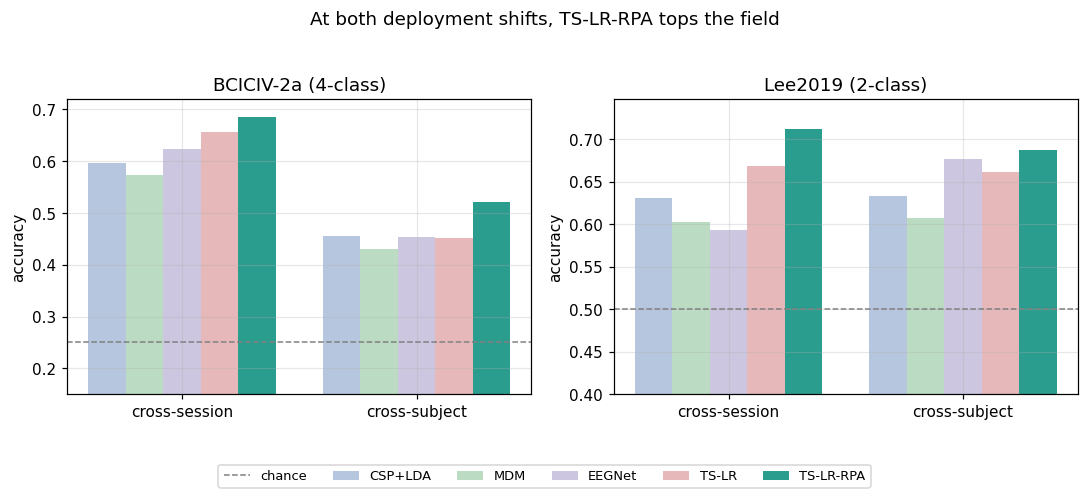

In [6]:
# RPA where it operates: at both deployment shifts, TS-LR-RPA tops the field
M5 = ["CSP+LDA", "MDM", "EEGNet", "TS-LR", "TS-LR-RPA"]
C5 = {**COLORS, "TS-LR-RPA": "#2A9D8F"}
protos = ["cross-session", "cross-subject"]

def shift_val(m, proto, crossdf, loso):
    return crossdf[crossdf.method == m].score.mean() if proto == "cross-session" else loso[m].mean()
    
fig, axes = plt.subplots(1, 2, figsize=(10, 4.4))
for ax, (name, crossdf, loso, chance) in zip(axes, [
        ("BCICIV-2a (4-class)", a_cross, a_loso_b, 0.25),
        ("Lee2019 (2-class)", lee_cross, l_loso_b, 0.50)]):
    x = np.arange(len(protos)); w = 0.16 
    for j, m in enumerate(M5):
        vals = [shift_val(m, p, crossdf, loso) for p in protos]
        ax.bar(x + (j - 2) * w, vals, w, color=C5[m], label=m,
               alpha=1.0 if m == "TS-LR-RPA" else 0.4)
    ax.axhline(chance, ls="--", c="gray", lw=1, label="chance")
    ax.set_ylim(bottom=chance-0.1)
    ax.set_xticks(x); ax.set_xticklabels(protos); ax.set_title(name); ax.set_ylabel("accuracy")
h, l = axes[0].get_legend_handles_labels()
fig.legend(h, l, loc="lower center", ncol=6, fontsize=8.5, bbox_to_anchor=(0.5, -0.02))
fig.suptitle("At both deployment shifts, TS-LR-RPA tops the field")
fig.tight_layout(rect=[0, 0.1, 1, 0.95]); plt.show()

**补完后 TS-LR-RPA 在两档协议都是第一(cross-session / cross-subject;通道缩减档 TS-LR 本就 9/10 格第一)。**

## 发现三:深度学习不是默认更好,EEGNet 的表现随数据机制起落

EEGNet的强弱完全取决于拿到的数据量+数据种类。下面用归一化κ,把 EEGNet(紫线)和三种参照方法(CSP/MDM/TS-LR)张成的灰色带放在一起,横轴是四种数据机制,2a 与 Lee 分上下两图对比。EEGNet线在灰带之内表示与主流方法相当,落到带下方表示比所有方法都差,冒到带上方表示最好。结论:在2a上EEGNet始终在带内(K=4通道极少时甚至冒到带上方,紧凑CNN的归纳偏置占便宜);但在Lee上,前三档(K=4 / 会话内 / 跨会话,每会话才 100 trial)EEGNet一直在带下方、比所有方法都差(量化看跨会话:EEGNet的κ从2a的约0.50掉到Lee的约0.19,降约63%,是四种方法里降幅最大的),直到跨被试(53个训练被试)才冒到带上方成为最好。结论:被试已知时瓶颈是每人trial数,被试未知时瓶颈是训练被试数。

### EEGNet 相对参照方法带(CSP/MDM/TS-LR)的 κ 随数据机制漂移

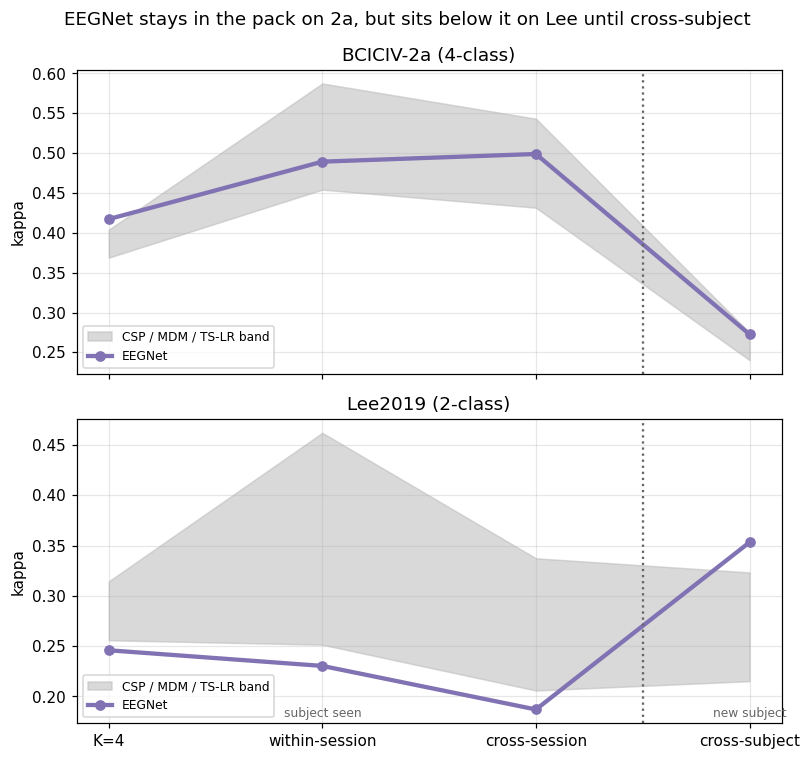

In [7]:
# EEGNet (line) vs the band spanned by the three reference methods (CSP/MDM/TS-LR), in kappa
kap = lambda acc, ch: (acc - ch) / (1 - ch)
REF = ["CSP+LDA", "MDM", "TS-LR"]
regimes = ["K=4", "within-session", "cross-session", "cross-subject"]
def kval(cr, fK, cd, lo, ch, m, reg):
    if reg == "K=4": return kap(cr[(cr.method == m) & (cr.n_channels == 4)].score.mean(), ch)
    if reg == "within-session": return kap(cr[(cr.method == m) & (cr.n_channels == fK)].score.mean(), ch)
    if reg == "cross-session": return kap(cd[cd.method == m].score.mean(), ch)
    return kap(lo[m].mean(), ch)
specs = [("BCICIV-2a (4-class)", a_cr, 22, a_cross, a_loso_b, 0.25),
         ("Lee2019 (2-class)", lee_cr, 62, lee_cross, l_loso_b, 0.50)]
fig, axes = plt.subplots(2, 1, figsize=(7.5, 7), sharex=True)
xs = list(range(len(regimes)))
for ax, (name, cr, fK, cd, lo, ch) in zip(axes, specs):
    band = [[kval(cr, fK, cd, lo, ch, m, r) for m in REF] for r in regimes]
    lo_b = [min(b) for b in band]; hi_b = [max(b) for b in band]
    eeg = [kval(cr, fK, cd, lo, ch, "EEGNet", r) for r in regimes]
    ax.fill_between(xs, lo_b, hi_b, color="#bbbbbb", alpha=0.55, label="CSP / MDM / TS-LR band")
    ax.plot(xs, eeg, "o-", color=COLORS["EEGNet"], lw=2.8, label="EEGNet")
    ax.axvline(2.5, color="0.4", ls=":", lw=1.5)
    ax.set_title(name); ax.set_ylabel("kappa"); ax.legend(fontsize=8, loc="best")
axes[1].set_xticks(xs); axes[1].set_xticklabels(regimes)
axes[1].text(1.0, 0.02, "subject seen", transform=axes[1].get_xaxis_transform(), ha="center", fontsize=8, color="0.4")
axes[1].text(3.0, 0.02, "new subject", transform=axes[1].get_xaxis_transform(), ha="center", fontsize=8, color="0.4")
fig.suptitle("EEGNet stays in the pack on 2a, but sits below it on Lee until cross-subject")
fig.tight_layout(); plt.show()

## 工程化:EEGNet 导出 ONNX + 推理延迟检查

把训练好的 EEGNet 导出成 ONNX,做一个推理延迟与部署一致性检查。延迟用单窗、batch=1、先 warmup 再逐次计时;一致性在 9 个被试的训练模型 x 各自真实 held-out 窗上,测 PyTorch 与 ONNX Runtime 的 logits 是否给出同样决策。

边界:这是 ONNX 导出加 onnxruntime 推理延迟的 demo,验证「可部署化」这条路走得通,不是真的跑在端侧硬件上。单窗 ONNX 延迟稳定在 ~0.17ms,PyTorch eager 侧逐次计时有抖动,所以加速比逐次在 3.4-3.6x 之间波动(典型 ~3.5x)。数字来自 `run_onnx_deploy_check.py` 写出的 `results/onnx_deploy_check.json`。

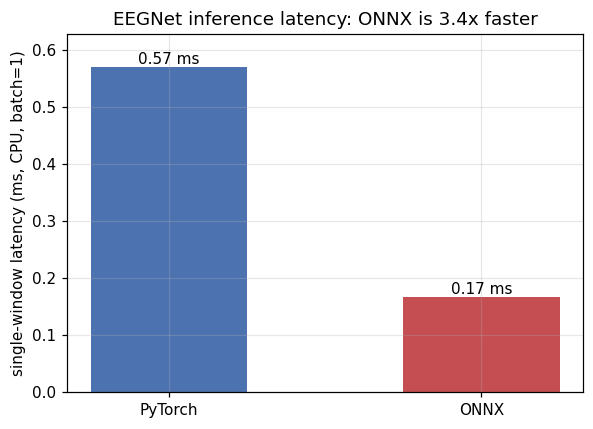

params: 2,548   ONNX size: 13.6 KB
ONNX latency p50/p95/p99 (ms): 0.166 / 0.185 / 0.195
speedup this run: 3.40x  (PyTorch eager timing jitters; ~3.5x typical, 3.4-3.6x across runs)
deployment parity: 9 subjects x 2592 real windows, label agreement 100.0%, worst max|d-logit| 1.14e-05


In [8]:
import json as _json
onnx = _json.load(open(RESULTS / "onnx_deploy_check.json"))
lat = onnx["latency_ms"]
backends = ["PyTorch", "ONNX"]
means = [lat[b]["mean"] for b in backends]

fig, ax = plt.subplots(figsize=(5.5, 4))
bars = ax.bar(backends, means, color=[COLORS["CSP+LDA"], COLORS["TS-LR"]], width=0.5)
for b, m in zip(bars, means):
    ax.text(b.get_x() + b.get_width() / 2, m, f"{m:.2f} ms", ha="center", va="bottom")
ax.set_ylabel("single-window latency (ms, CPU, batch=1)")
ax.set_title(f"EEGNet inference latency: ONNX is {onnx['speedup']:.1f}x faster")
ax.set_ylim(0, max(means) * 1.1)
fig.tight_layout(); plt.show()

print(f"params: {onnx['n_params']:,}   ONNX size: {onnx['onnx_kb']:.1f} KB")
print(f"ONNX latency p50/p95/p99 (ms): "
      f"{lat['ONNX']['p50']:.3f} / {lat['ONNX']['p95']:.3f} / {lat['ONNX']['p99']:.3f}")
print(f"speedup this run: {onnx['speedup']:.2f}x  "
      f"(PyTorch eager timing jitters; ~3.5x typical, 3.4-3.6x across runs)")
print(f"deployment parity: {onnx['n_subjects']} subjects x {onnx['n_windows_total']} real windows, "
      f"label agreement {onnx['worst_label_agreement'] * 100:.1f}%, "
      f"worst max|d-logit| {onnx['worst_max_abs_diff']:.2e}")

## 结论

1. **TS-LR(黎曼切空间)在 within-session 与跨会话最稳**:这两个协议 × 两个数据集全排第一(协议格子 1/1/1/1)。通道缩减时也基本最优,唯一例外是 2a 砍到 4 通道,EEGNet 点估计反超(0.563 vs 0.553,差 0.01、不到 1 个 SD,且该 K 下 Friedman p=0.14、方法间无显著差异)。跨被试上基线 TS-LR 不再领先(Lee 上 EEGNet 在 base 方法里第一、2a 上与 CSP/EEGNet 三者并列),但经 RPA 后两数据集都回到所有方法第一(即:加上 RPA 后,TS-LR-RPA 在全部四档协议都是第一)。
2. **RPA 在跨会话与跨被试上都能恢复退化,且都要看样本量**:跨会话同样大小的效应,9 人时 p=0.055(不显著)、54 人时 p=2.5e-5(显著);跨被试上 2a +0.069(p=0.02,9 人即显著,因为漂移更大、可纠正的更多)、Lee +0.026(p=2.8e-4)。两个协议、两个数据集都复现。
3. **n=9 的检验功效取决于效应大小**:跨会话退化幅度小,9 人时检测不到(p>0.05)、54 人才显著(p<3e-5),直接说明换大数据集的必要性;但跨被试退化幅度大,2a 即便 9 人也显著(所有被试一致下降)。
4. **EEGNet 数据饥饿,但"缺哪种数据"取决于协议**:within-subject 协议(同会话、通道、跨会话)缺的是每人 trial 数,Lee2019 每会话才 100 个 trial,EEGNet 这三档全排末位;跨被试 LOSO 缺的是训练被试数,2a 只有 8 个训练被试,EEGNet 与经典方法并列(0.454),Lee2019 有 53 个被试,EEGNet 反而是 base 方法第一(0.677),甚至超过它自己的同会话天花板(0.615 升到 0.677,p=2.6e-4)。结论:标定稀缺时经典方法更稳,深网要等数据(trial 或被试)足够才追上来。
5. **复现核对(把 2a 的发现拿到 Lee2019 上验证)**:"通道越多、各方法差距越大" 复现成立;"2a 上 K=4 时 EEGNet 最强" 在 Lee2019 上反转(那里它最差);"EEGNet 退化最小" 实为 floor effect,非真鲁棒;"RPA 补回跨会话损失" 复现且大样本显著;"RPA 补回跨被试损失" 两数据集都显著。

方法学:所有对比用 Friedman + Wilcoxon(Holm 校正),报告效应量 dz,并对随机水平用 κ 归一化。

## 局限与下一步

**局限:**
- 部分「鲁棒」其实是 floor effect(EEGNet 退化最小,部分因为它本就接近随机水平),已显式标注,不当作真鲁棒。
- 只覆盖两个公开数据集;离线评估,没有在线闭环。
- RPA 平均有效,但非对每个人都正(Lee2019 上 54 人里 37 升、13 降),反映人群异质与个别被试负迁移。

**下一步:**
- 把这套鲁棒性 benchmark 方法学扩到多模态(EEG + fNIRS),黎曼协方差方法天然可扩展;我有 2 年 fMRI 全流程分析经验,具备多模态背景。
- 给定真实临床数据,先量化跨会话/跨被试掉落(没量化就无法改进),再在「降标定(RPA 式)」与「加标定」之间权衡。